# Non-invasive glucose — data & domain analysis

**Goal:** Understand the raw dataset (`clean-dataset.csv`), document **leakage and quality issues**, then reproduce **step-by-step** how we arrived at **`clean-dataset-relevant.csv`** for ML.

**Domain:** PPG-derived features + demographics → predict **`Glucose_level` (mg/dL)**. This notebook is for **engineering / FYP**: prototype rigor, not medical certification.


In [51]:
# Setup
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: faster models for large-N demo
try:
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.model_selection import GroupShuffleSplit, train_test_split
    from sklearn.metrics import mean_absolute_error
    HAS_SKLEARN = True
except ImportError:
    HAS_SKLEARN = False
    print("Install scikit-learn for split/leakage demo cells.")

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 12

# Paths (same folder as this notebook by default)
BASE = Path(r"c:\Users\555555\OneDrive\Desktop\GLUCOSE")
ORIGINAL = BASE / "clean-dataset.csv"
RELEVANT = BASE / "clean-dataset-relevant.csv"
REPORT = BASE / "clean-dataset-relevant-report.json"

assert ORIGINAL.exists(), f"Missing {ORIGINAL}"
print("BASE:", BASE.resolve())


BASE: C:\Users\555555\OneDrive\Desktop\GLUCOSE


## 1. Load original dataset

We start from **`clean-dataset.csv`** — full row count before any cleaning.


In [52]:
df_raw = pd.read_csv(ORIGINAL)
print("Shape:", df_raw.shape)
print("Columns:", list(df_raw.columns))
df_raw.head(10)


Shape: (844946, 13)
Columns: ['PPG_Signal', 'Patient_Id', 'Heart_Rate', 'Systolic_Peak', 'Diastolic_Peak', 'Pulse_Area', 'index', 'Gender', 'Age', 'Glucose_level', 'Height', 'Weight', 'pl']


,PPG_Signal,Patient_Id,Heart_Rate,Systolic_Peak,Diastolic_Peak,Pulse_Area,index,Gender,Age,Glucose_level,Height,Weight,pl
0,511,1,77.0,522.0,505.0,393.0,0,1,38,99,180,53,1
1,511,1,77.0,522.0,505.0,393.0,1,1,38,102,180,53,2
2,511,1,77.0,522.0,505.0,393.0,2,1,38,103,180,53,3
3,511,1,77.0,522.0,505.0,393.0,3,1,38,128,180,53,4
4,511,1,77.0,522.0,505.0,393.0,4,1,38,130,180,53,5
5,511,1,77.0,522.0,505.0,393.0,5,1,38,134,180,53,6
6,511,1,77.0,522.0,505.0,393.0,6,1,38,136,180,53,7
7,511,1,77.0,522.0,505.0,393.0,0,1,38,99,180,53,8
8,511,1,77.0,522.0,505.0,393.0,1,1,38,102,180,53,9
9,511,1,77.0,522.0,505.0,393.0,2,1,38,103,180,53,10


In [53]:
# Quick dtypes and missing values
info = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "missing": df_raw.isna().sum(),
    "n_unique": df_raw.nunique(),
})
info


,dtype,missing,n_unique
PPG_Signal,int64,0,12
Patient_Id,int64,0,22
Heart_Rate,float64,0,32
Systolic_Peak,float64,0,16
Diastolic_Peak,float64,0,9
Pulse_Area,float64,0,92
index,int64,0,62
Gender,int64,0,2
Age,int64,0,16
Glucose_level,int64,0,28


## 2. Domain summary (what each column means operationally)

| Column | Role |
|--------|------|
| `PPG_Signal`, `Systolic_Peak`, `Diastolic_Peak`, `Pulse_Area` | **Waveform / amplitude features** (sensor scale, not necessarily mmHg BP) |
| `Heart_Rate` | Pulse rate |
| `Gender`, `Age`, `Height`, `Weight` | Demographics / anthropometry |
| `Glucose_level` | **Target** — reference glucose (mg/dL) for training |
| `Patient_Id` | Subject identifier — use for **grouped splits**, not as a casual numeric feature |
| `index`, `pl` | **Metadata / ordering** — high leakage risk |


## 3. Target & key inputs — distributions (original data)

For speed, we plot **histograms on a random sample** if the file is very large (set `MAX_PLOT` below).


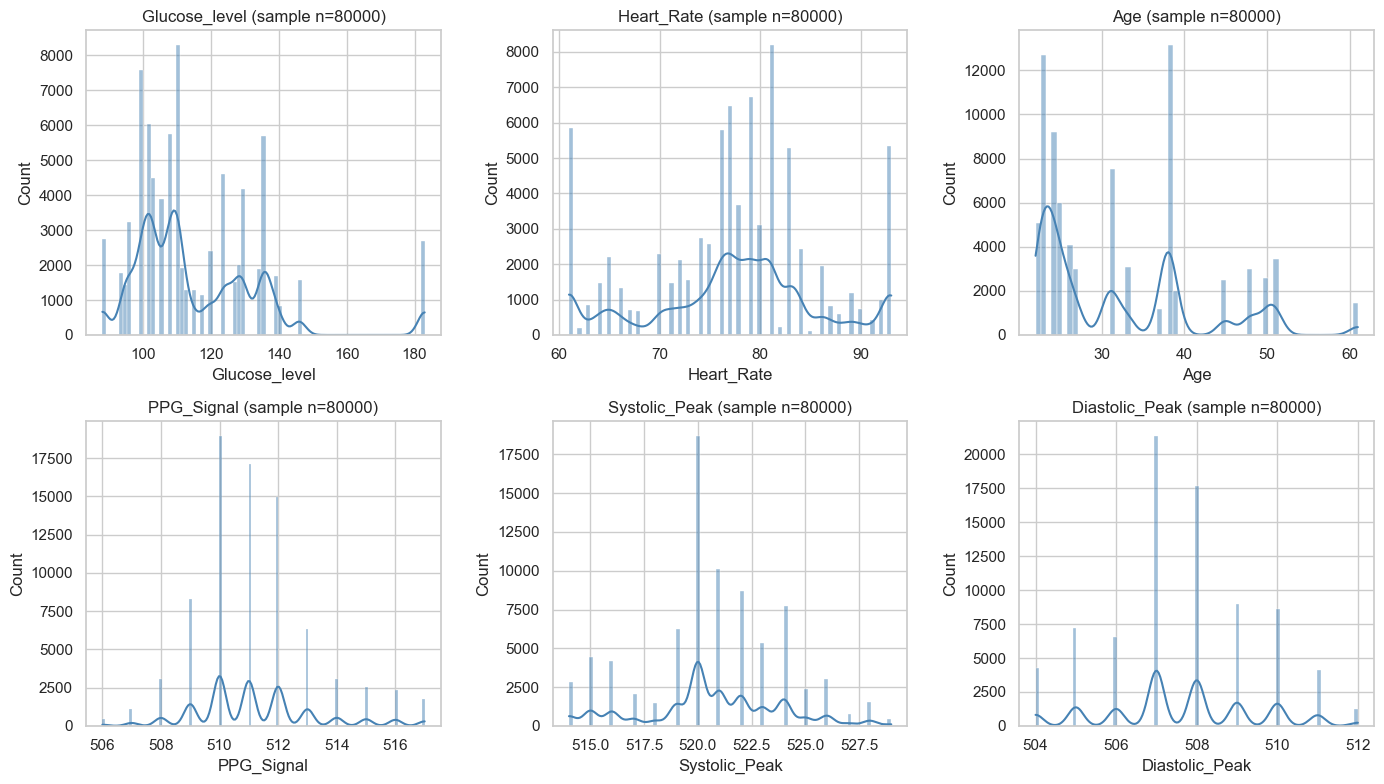

In [54]:
MAX_PLOT = 80_000  # increase if you have RAM/time
rng = np.random.default_rng(42)
n = len(df_raw)
idx = rng.choice(n, size=min(n, MAX_PLOT), replace=False) if n > MAX_PLOT else np.arange(n)
sample = df_raw.iloc[idx]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
for ax, col in zip(
    axes,
    ["Glucose_level", "Heart_Rate", "Age", "PPG_Signal", "Systolic_Peak", "Diastolic_Peak"],
):
    if col in sample.columns:
        sns.histplot(sample[col].dropna(), kde=True, ax=ax, color="steelblue")
        ax.set_title(f"{col} (sample n={len(sample)})")
plt.tight_layout()
plt.show()


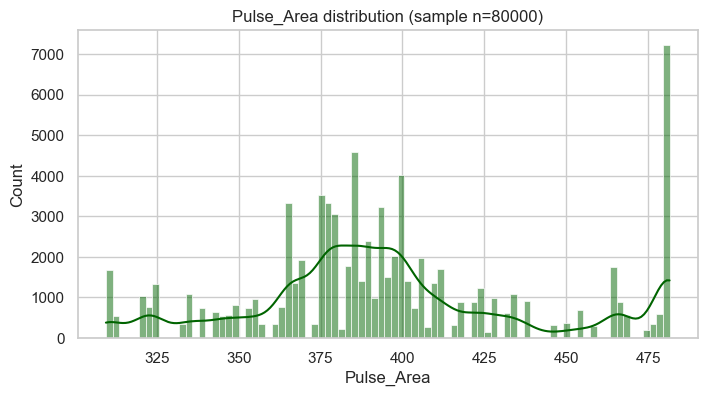

In [55]:
# Pulse_Area distribution
plt.figure(figsize=(8, 4))
sns.histplot(sample["Pulse_Area"].dropna(), kde=True, color="darkgreen")
plt.title(f"Pulse_Area distribution (sample n={len(sample)})")
plt.show()


## 4. Leakage audit — why `index` and `pl` are dangerous

**Goal:** Detect columns that let the model memorize order/IDs instead of physiology.


In [56]:
# Cardinality & correlation with target
y = df_raw["Glucose_level"]
for c in ["index", "pl", "Patient_Id"]:
    if c in df_raw.columns:
        nu = df_raw[c].nunique()
        cc = df_raw[c].corr(y)
        print(f"{c:12} nunique={nu:10}  corr(glucose)={cc:.4f}")


index        nunique=        62  corr(glucose)=-0.1622
pl           nunique=    844946  corr(glucose)=-0.0131
Patient_Id   nunique=        22  corr(glucose)=0.0056


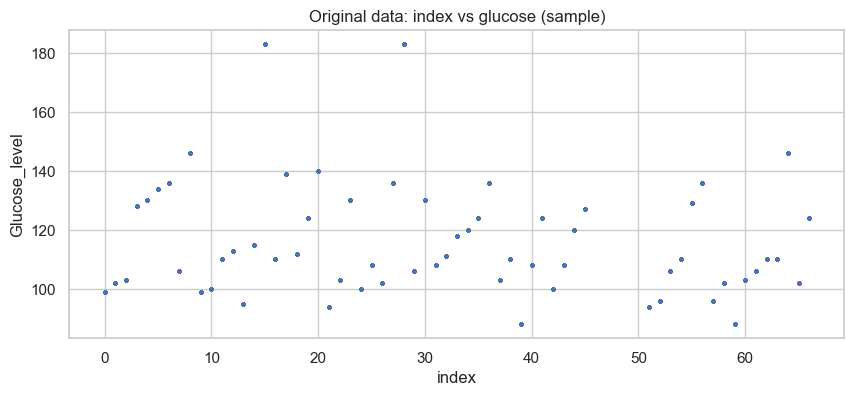

In [57]:
# Visual: index vs glucose (sample) — often structured, not random measurement noise
s = sample.copy()
plt.figure(figsize=(10, 4))
plt.scatter(s["index"], s["Glucose_level"], alpha=0.15, s=4)
plt.xlabel("index")
plt.ylabel("Glucose_level")
plt.title("Original data: index vs glucose (sample)")
plt.show()


In [58]:
# Duplicate structure (two different summaries — both are correct)
phys_key = [
    "PPG_Signal", "Patient_Id", "Heart_Rate", "Systolic_Peak", "Diastolic_Peak",
    "Pulse_Area", "Gender", "Age", "Height", "Weight",
]
phys_key = [c for c in phys_key if c in df_raw.columns]
# Rows that share the same physiology+demographics as an earlier row (index/pl/glucose may differ)
dup_after_first_phys = df_raw.duplicated(subset=phys_key).sum()
print("Rows with repeated physiology+demographics (2nd+ occurrence; excludes index/pl from key):", int(dup_after_first_phys))

# Matches build_relevant_dataset.py step 2: drop index/pl, then count exact duplicate rows
_df = df_raw.drop(columns=[c for c in ["index", "pl"] if c in df_raw.columns])
full_row_dups_ignoring_meta = int(_df.duplicated().sum())
print("Exact duplicate rows AFTER dropping index/pl (same as pipeline duplicate removal):", full_row_dups_ignoring_meta)


Rows with repeated physiology+demographics (2nd+ occurrence; excludes index/pl from key): 842604
Exact duplicate rows AFTER dropping index/pl (same as pipeline duplicate removal): 837678


In [59]:
if HAS_SKLEARN:
    feats_leak = ["PPG_Signal", "Heart_Rate", "Systolic_Peak", "Diastolic_Peak", "Pulse_Area",
                  "index", "Gender", "Age", "Height", "Weight", "pl"]
    feats_leak = [c for c in feats_leak if c in df_raw.columns]
    feats_safe = [c for c in feats_leak if c not in ("index", "pl")]

    # Subsample for speed
    sub_n = min(120_000, len(df_raw))
    sub = df_raw.sample(sub_n, random_state=42)
    y = sub["Glucose_level"]

    def mae_split(X, y, groups, use_group):
        if use_group:
            gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
            tr, te = next(gss.split(X, y, groups=groups))
            Xtr, Xte = X.iloc[tr], X.iloc[te]
            ytr, yte = y.iloc[tr], y.iloc[te]
        else:
            Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
        m = RandomForestRegressor(n_estimators=60, max_depth=12, random_state=42, n_jobs=-1)
        m.fit(Xtr, ytr)
        return mean_absolute_error(yte, m.predict(Xte))

    Xl = sub[feats_leak]
    Xs = sub[feats_safe]
    g = sub["Patient_Id"]

    print("MAE with index+pl, random split:  ", round(mae_split(Xl, y, g, False), 4))
    print("MAE with index+pl, group Patient_Id:", round(mae_split(Xl, y, g, True), 4))
    print("MAE no index/pl, random split:     ", round(mae_split(Xs, y, g, False), 4))
    print("MAE no index/pl, group Patient_Id: ", round(mae_split(Xs, y, g, True), 4))
else:
    print("Skipping RF demo (sklearn not installed).")


MAE with index+pl, random split:   0.0614
MAE with index+pl, group Patient_Id: 24.6872
MAE no index/pl, random split:      11.4988
MAE no index/pl, group Patient_Id:  17.0996


## 5. Step-by-step pipeline → `clean-dataset-relevant.csv`

This mirrors `build_relevant_dataset.py`. After each step we record **row counts** for transparency.


In [60]:
def clip_range_mask(s, low, high):
    return (s < low) | (s > high)

def robust_iqr_mask(series, multiplier=3.0):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    low = q1 - multiplier * iqr
    high = q3 + multiplier * iqr
    return (series < low) | (series > high)

steps = []

df = pd.read_csv(ORIGINAL)
steps.append(("0_original", len(df)))

drop_cols = [c for c in ["index", "pl"] if c in df.columns]
df = df.drop(columns=drop_cols)
steps.append(("1_drop_index_pl", len(df)))

full_dup_removed = int(df.duplicated().sum())
df = df.drop_duplicates().copy()
steps.append(("2_drop_full_duplicates", len(df)))

range_rules = {
    "Heart_Rate": (30, 220),
    "Age": (10, 100),
    "Height": (120, 230),
    "Weight": (30, 250),
    "Glucose_level": (40, 500),
}
for col, (lo, hi) in range_rules.items():
    if col in df.columns:
        df = df[(df[col] >= lo) & (df[col] <= hi)]
steps.append(("3_physiology_filters", len(df)))

signal_cols = [c for c in ["PPG_Signal", "Systolic_Peak", "Diastolic_Peak", "Pulse_Area"] if c in df.columns]
for col in signal_cols:
    df = df[~robust_iqr_mask(df[col], 3.0)]
steps.append(("4_iqr_signal_cols", len(df)))

state_cols = [
    "Patient_Id", "PPG_Signal", "Heart_Rate", "Systolic_Peak", "Diastolic_Peak",
    "Pulse_Area", "Gender", "Age", "Height", "Weight",
]
state_cols = [c for c in state_cols if c in df.columns]

pre_conflict = len(df)
conflict_frame = df.groupby(state_cols, as_index=False)["Glucose_level"].agg(nunique="nunique", count="count")
n_conflicting_states = int((conflict_frame["nunique"] > 1).sum())

df = df.groupby(state_cols, as_index=False)["Glucose_level"].median()
steps.append(("5_median_glucose_per_state", len(df)))

# Engineered features (same as script)
if "Gender" in df.columns:
    df["Gender_Binary"] = df["Gender"].map({1: 0, 2: 1}).fillna(0).astype(int)
df["Height_m"] = df["Height"] / 100.0
df["BMI"] = df["Weight"] / (df["Height_m"] ** 2)
df["BSA_Mosteller"] = np.sqrt((df["Height"] * df["Weight"]) / 3600.0)
df["PulsePressure"] = df["Systolic_Peak"] - df["Diastolic_Peak"]
df["MAP"] = df["Diastolic_Peak"] + (df["PulsePressure"] / 3.0)
df["RPP"] = df["Heart_Rate"] * df["Systolic_Peak"]
df["ShockIndex"] = df["Heart_Rate"] / df["Systolic_Peak"].replace(0, np.nan)
df["PulseArea_per_HR"] = df["Pulse_Area"] / df["Heart_Rate"].replace(0, np.nan)
df["PulseArea_per_PP"] = df["Pulse_Area"] / df["PulsePressure"].replace(0, np.nan)

keep_cols = [
    "Patient_Id", "PPG_Signal", "Heart_Rate", "Systolic_Peak", "Diastolic_Peak", "Pulse_Area",
    "Gender", "Gender_Binary", "Age", "Height", "Weight", "Height_m", "BMI", "BSA_Mosteller",
    "PulsePressure", "MAP", "RPP", "ShockIndex", "PulseArea_per_HR", "PulseArea_per_PP", "Glucose_level",
]
keep_cols = [c for c in keep_cols if c in df.columns]
df = df[keep_cols]
df = df.replace([np.inf, -np.inf], np.nan).dropna()
steps.append(("6_after_nan_drop", len(df)))

df = df.drop_duplicates(subset=state_cols, keep="first").reset_index(drop=True)
steps.append(("7_final_unique_state", len(df)))

trail = pd.DataFrame(steps, columns=["step", "rows"])
trail


,step,rows
0,0_original,844946
1,1_drop_index_pl,844946
2,2_drop_full_duplicates,7268
3,3_physiology_filters,7268
4,4_iqr_signal_cols,7268
5,5_median_glucose_per_state,2342
6,6_after_nan_drop,2342
7,7_final_unique_state,2342


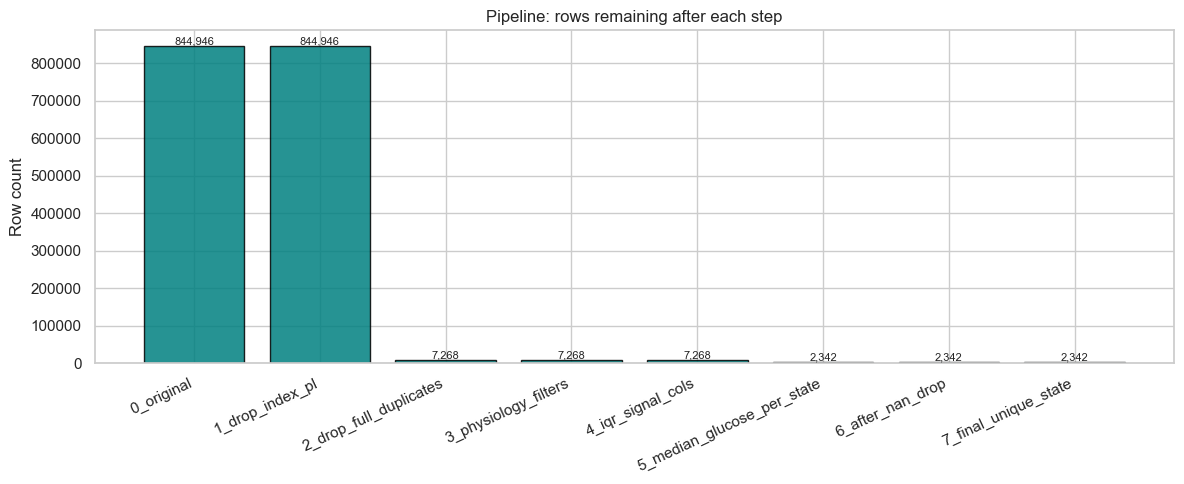

Conflicting states (before median merge): 2320
Full duplicate rows removed at step 2: 837678


In [61]:
# Waterfall-style bar: row counts through pipeline
plt.figure(figsize=(12, 5))
x = np.arange(len(trail))
plt.bar(x, trail["rows"], color="teal", edgecolor="black", alpha=0.85)
plt.xticks(x, trail["step"], rotation=25, ha="right")
plt.ylabel("Row count")
plt.title("Pipeline: rows remaining after each step")
for i, v in enumerate(trail["rows"]):
    plt.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8, rotation=0)
plt.tight_layout()
plt.show()

print("Conflicting states (before median merge):", n_conflicting_states)
print("Full duplicate rows removed at step 2:", full_dup_removed)


In [62]:
# Integrity check: one glucose per physiological state
gcheck = df.groupby(state_cols)["Glucose_level"].nunique()
print("max distinct glucose values per state:", int(gcheck.max()))
print("conflicting states:", int((gcheck > 1).sum()))


max distinct glucose values per state: 1
conflicting states: 0


## 6. Load saved `clean-dataset-relevant.csv` & compare distributions

Compare **target** and key features **before vs after** cleaning.


In [63]:
df_final = pd.read_csv(RELEVANT)
print("Final file shape:", df_final.shape)
if REPORT.exists():
    print("Report JSON keys:", list(json.loads(REPORT.read_text()).keys()))
df_final.head()


Final file shape: (2342, 21)
Report JSON keys: ['input_file', 'output_file', 'original_rows', 'full_duplicate_rows_removed', 'after_full_dedup_rows', 'after_physiology_filter_rows', 'iqr_rows_removed_total', 'conflicting_states_resolved_by_median', 'after_conflict_resolution_rows', 'nan_inf_rows_removed', 'final_rows', 'dropped_columns', 'state_columns_for_uniqueness', 'outlier_rows_detected_by_column', 'iqr_outlier_rows_detected_by_signal_column', 'final_columns']


,Patient_Id,PPG_Signal,Heart_Rate,Systolic_Peak,Diastolic_Peak,Pulse_Area,Gender,Gender_Binary,Age,Height,...,Height_m,BMI,BSA_Mosteller,PulsePressure,MAP,RPP,ShockIndex,PulseArea_per_HR,PulseArea_per_PP,Glucose_level
0,1,506,75.0,522.0,505.0,406.0,1,0,38,180,...,1.8,16.358025,1.627882,17.0,510.666667,39150.0,0.143678,5.413333,23.882353,128.0
1,1,507,75.0,522.0,505.0,406.0,1,0,38,180,...,1.8,16.358025,1.627882,17.0,510.666667,39150.0,0.143678,5.413333,23.882353,128.0
2,1,507,77.0,522.0,505.0,393.0,1,0,38,180,...,1.8,16.358025,1.627882,17.0,510.666667,40194.0,0.147510,5.103896,23.117647,128.0
3,1,508,75.0,522.0,505.0,406.0,1,0,38,180,...,1.8,16.358025,1.627882,17.0,510.666667,39150.0,0.143678,5.413333,23.882353,128.0
4,1,508,76.0,522.0,508.0,399.0,1,0,38,180,...,1.8,16.358025,1.627882,14.0,512.666667,39672.0,0.145594,5.250000,28.500000,128.0


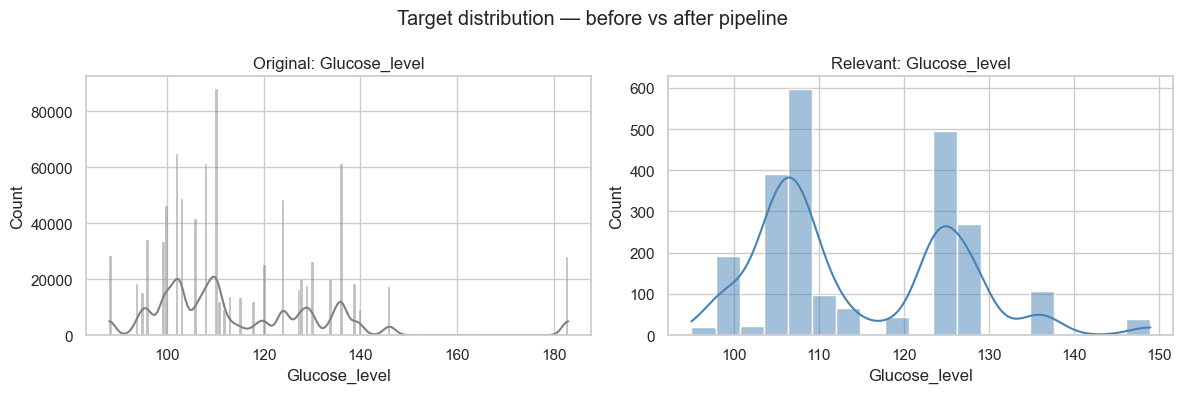

In [64]:
# Align for comparison: sample same columns from raw (post-load)
df_raw_s = pd.read_csv(ORIGINAL)
col_g = "Glucose_level"
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_raw_s[col_g].dropna(), kde=True, ax=axes[0], color="gray")
axes[0].set_title("Original: Glucose_level")
sns.histplot(df_final[col_g].dropna(), kde=True, ax=axes[1], color="steelblue")
axes[1].set_title("Relevant: Glucose_level")
plt.suptitle("Target distribution — before vs after pipeline")
plt.tight_layout()
plt.show()


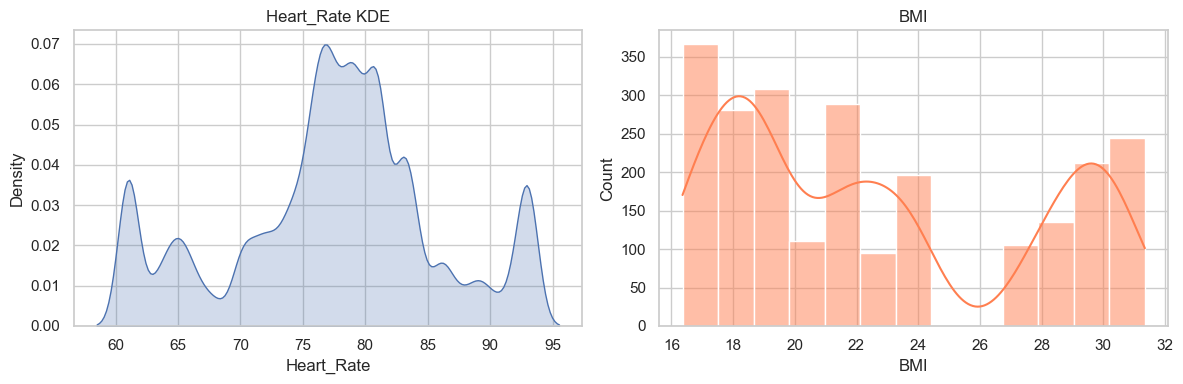

In [65]:
# KDE overlay for BMI (only on final) and Heart_Rate comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if "Heart_Rate" in df_raw_s.columns:
    sns.kdeplot(df_raw_s["Heart_Rate"].sample(min(len(df_raw_s), 100_000), random_state=42), ax=axes[0], fill=True, label="original sample")
    axes[0].set_title("Heart_Rate KDE")
if "BMI" in df_final.columns:
    sns.histplot(df_final["BMI"], kde=True, ax=axes[1], color="coral")
    axes[1].set_title("BMI")
plt.tight_layout()
plt.show()


## 7. Domain thresholds — glucose bands (for dashboards / alerts)

Standard prototype bands (e.g. Low **&lt;70**, Normal **70–140**, Elevated **140–179**, High **≥180**) are **absolute clinical cutoffs**.  
our `clean-dataset-relevant.csv` target in this project spans roughly **95–149 mg/dL** — so almost every row falls in **Normal**, a few in **Elevated**, and **none** in Low/High.

For dashboards on **this** data, also report **within-range** variation (histogram below) or **quantile** bands if you need more even groups for **illustration** (with a clear disclaimer).


Target in this file — min / max / mean (mg/dL): 95.0 149.0 114.5


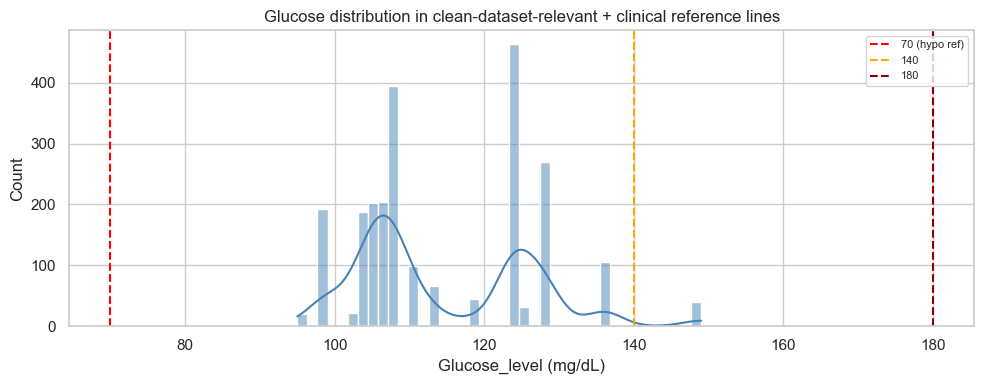


Counts per clinical-style band:
Glucose_level
Low            0
Normal      2302
Elevated      40
High           0

% in Normal: 98.3


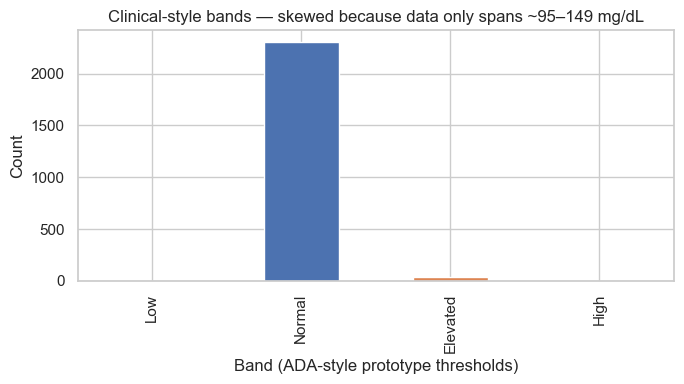

Glucose_level
Low            0
Normal      2302
Elevated      40
High           0
Name: count, dtype: int64

In [66]:
def glucose_band(mgdl):
    if mgdl < 70:
        return "Low"
    if mgdl <= 140:
        return "Normal"
    if mgdl < 180:
        return "Elevated"
    return "High"

gcol = "Glucose_level"
print(
    "Target in this file — min / max / mean (mg/dL):",
    float(df_final[gcol].min()),
    float(df_final[gcol].max()),
    round(float(df_final[gcol].mean()), 2),
)

# 1) Histogram + clinical reference lines (shows WHY bands are skewed)
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(df_final[gcol], kde=True, ax=ax, color="steelblue", bins=40)
for x, lab, c in [(70, "70 (hypo ref)", "red"), (140, "140", "orange"), (180, "180", "darkred")]:
    ax.axvline(x, color=c, ls="--", lw=1.5, label=lab)
ax.set_xlabel("Glucose_level (mg/dL)")
ax.set_title("Glucose distribution in clean-dataset-relevant + clinical reference lines")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

# 2) Counts per absolute band (expect ~all Normal if data never goes &lt;70 or ≥180)
bands = df_final[gcol].apply(glucose_band)
bc = bands.value_counts().reindex(["Low", "Normal", "Elevated", "High"], fill_value=0)
print("\nCounts per clinical-style band:")
print(bc.to_string())
print("\n% in Normal:", round(100 * bc["Normal"] / len(df_final), 1))

plt.figure(figsize=(7, 4))
bc.plot(kind="bar", color=["#c44e52", "#4c72b0", "#dd8452", "#55a868"])
plt.title("Clinical-style bands — skewed because data only spans ~95–149 mg/dL")
plt.ylabel("Count")
plt.xlabel("Band (ADA-style prototype thresholds)")
plt.tight_layout()
plt.show()
bc


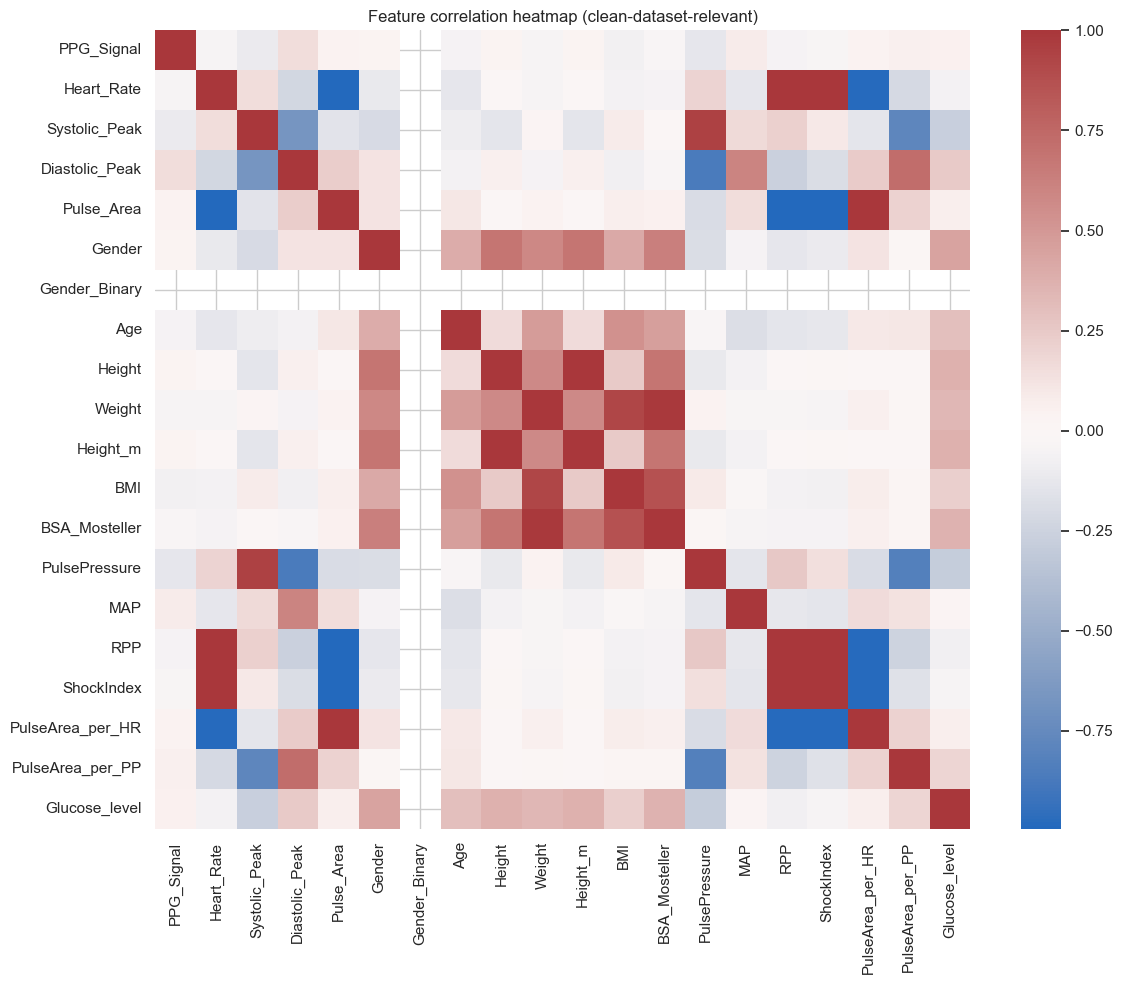

In [67]:
# Correlation matrix — final numeric features (excluding Patient_Id)
num_cols = df_final.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ("Patient_Id",)]
cm = df_final[num_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap="vlag", center=0, square=False)
plt.title("Feature correlation heatmap (clean-dataset-relevant)")
plt.tight_layout()
plt.show()


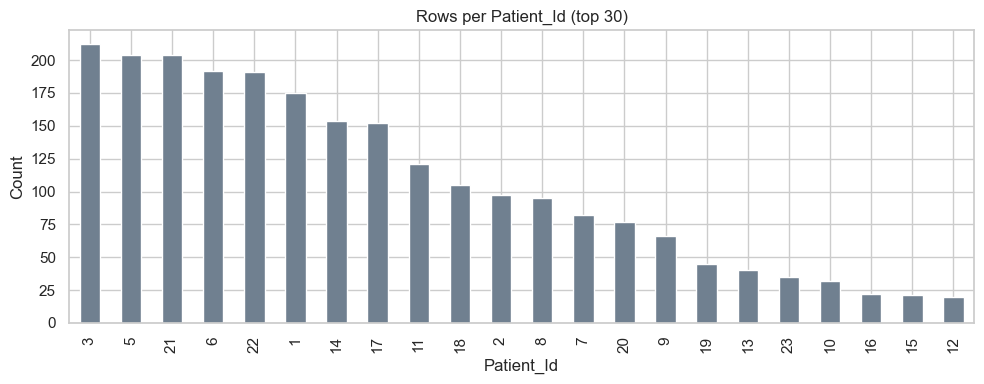

Patients: 22  | Total rows: 2342


In [68]:
# Per-patient sample sizes
pc = df_final.groupby("Patient_Id").size().sort_values(ascending=False)
plt.figure(figsize=(10, 4))
pc.head(30).plot(kind="bar", color="slategray")
plt.title("Rows per Patient_Id (top 30)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()
print("Patients:", df_final["Patient_Id"].nunique(), " | Total rows:", len(df_final))


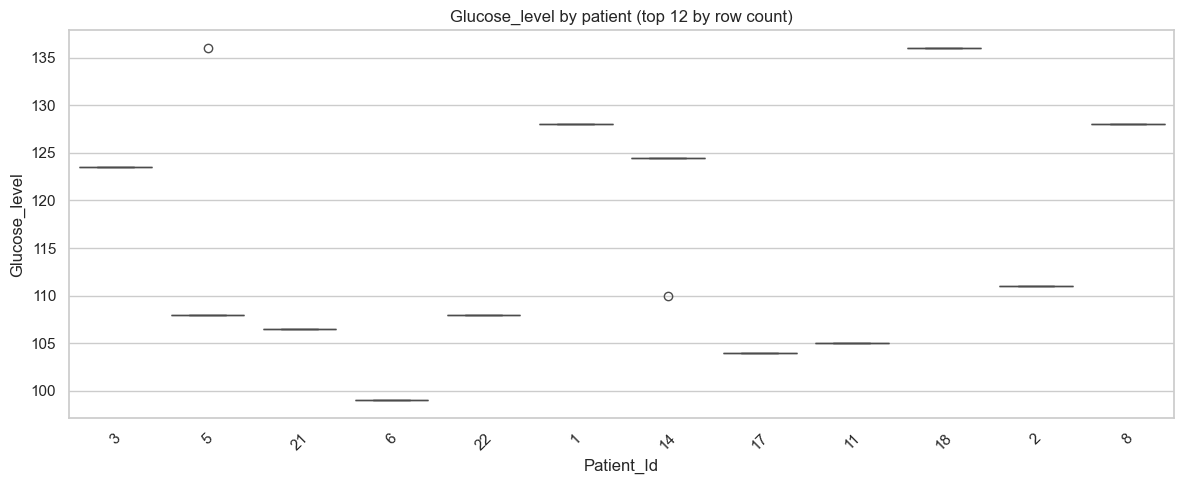

In [69]:
# Boxplot: glucose distribution per patient (top 12 by count)
top_patients = pc.head(12).index
sub = df_final[df_final["Patient_Id"].isin(top_patients)]
plt.figure(figsize=(12, 5))
sns.boxplot(data=sub, x="Patient_Id", y="Glucose_level", order=top_patients)
plt.xticks(rotation=45)
plt.title("Glucose_level by patient (top 12 by row count)")
plt.tight_layout()
plt.show()


## 7b. Extra visuals — relationships (final dataset)

Use these to decide which engineered features deserve modeling focus.


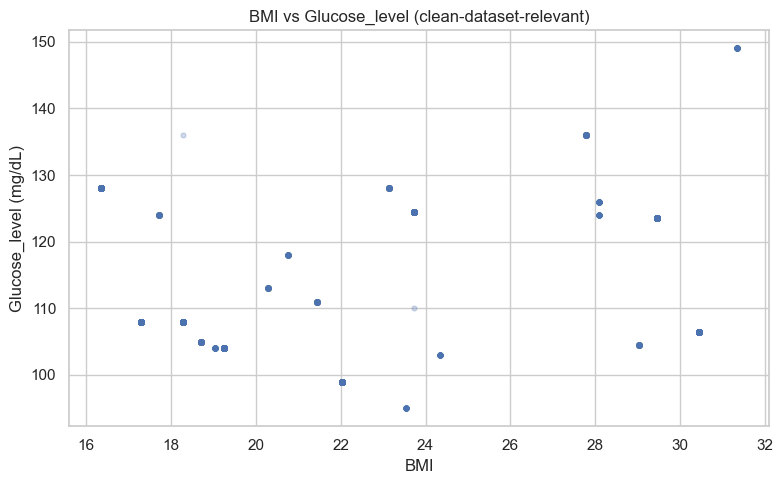

In [70]:
# Scatter: BMI vs glucose (density via alpha)
plt.figure(figsize=(8, 5))
plt.scatter(df_final["BMI"], df_final["Glucose_level"], alpha=0.25, s=12)
plt.xlabel("BMI")
plt.ylabel("Glucose_level (mg/dL)")
plt.title("BMI vs Glucose_level (clean-dataset-relevant)")
plt.tight_layout()
plt.show()


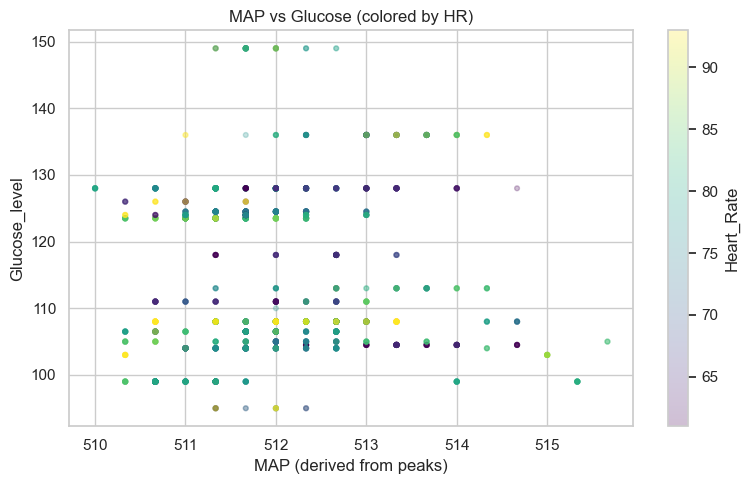

In [71]:
# Scatter: MAP (signal-scale proxy) vs glucose
plt.figure(figsize=(8, 5))
plt.scatter(df_final["MAP"], df_final["Glucose_level"], alpha=0.25, s=12, c=df_final["Heart_Rate"], cmap="viridis")
plt.colorbar(label="Heart_Rate")
plt.xlabel("MAP (derived from peaks)")
plt.ylabel("Glucose_level")
plt.title("MAP vs Glucose (colored by HR)")
plt.tight_layout()
plt.show()


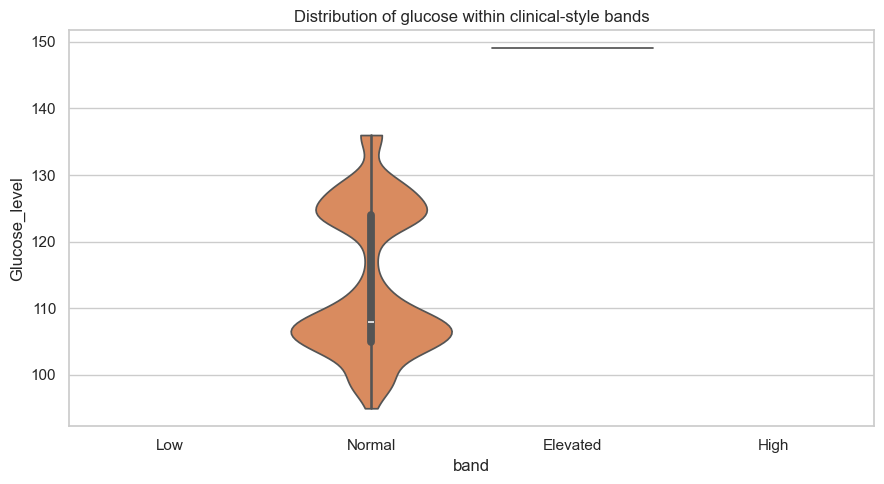

In [72]:
# Violin: glucose by band (after labeling)
bands = df_final["Glucose_level"].apply(glucose_band)
plot_df = df_final.copy()
plot_df["band"] = bands
order = ["Low", "Normal", "Elevated", "High"]
plt.figure(figsize=(9, 5))
sns.violinplot(data=plot_df, x="band", y="Glucose_level", order=order, palette="muted", cut=0)
plt.title("Distribution of glucose within clinical-style bands")
plt.tight_layout()
plt.show()


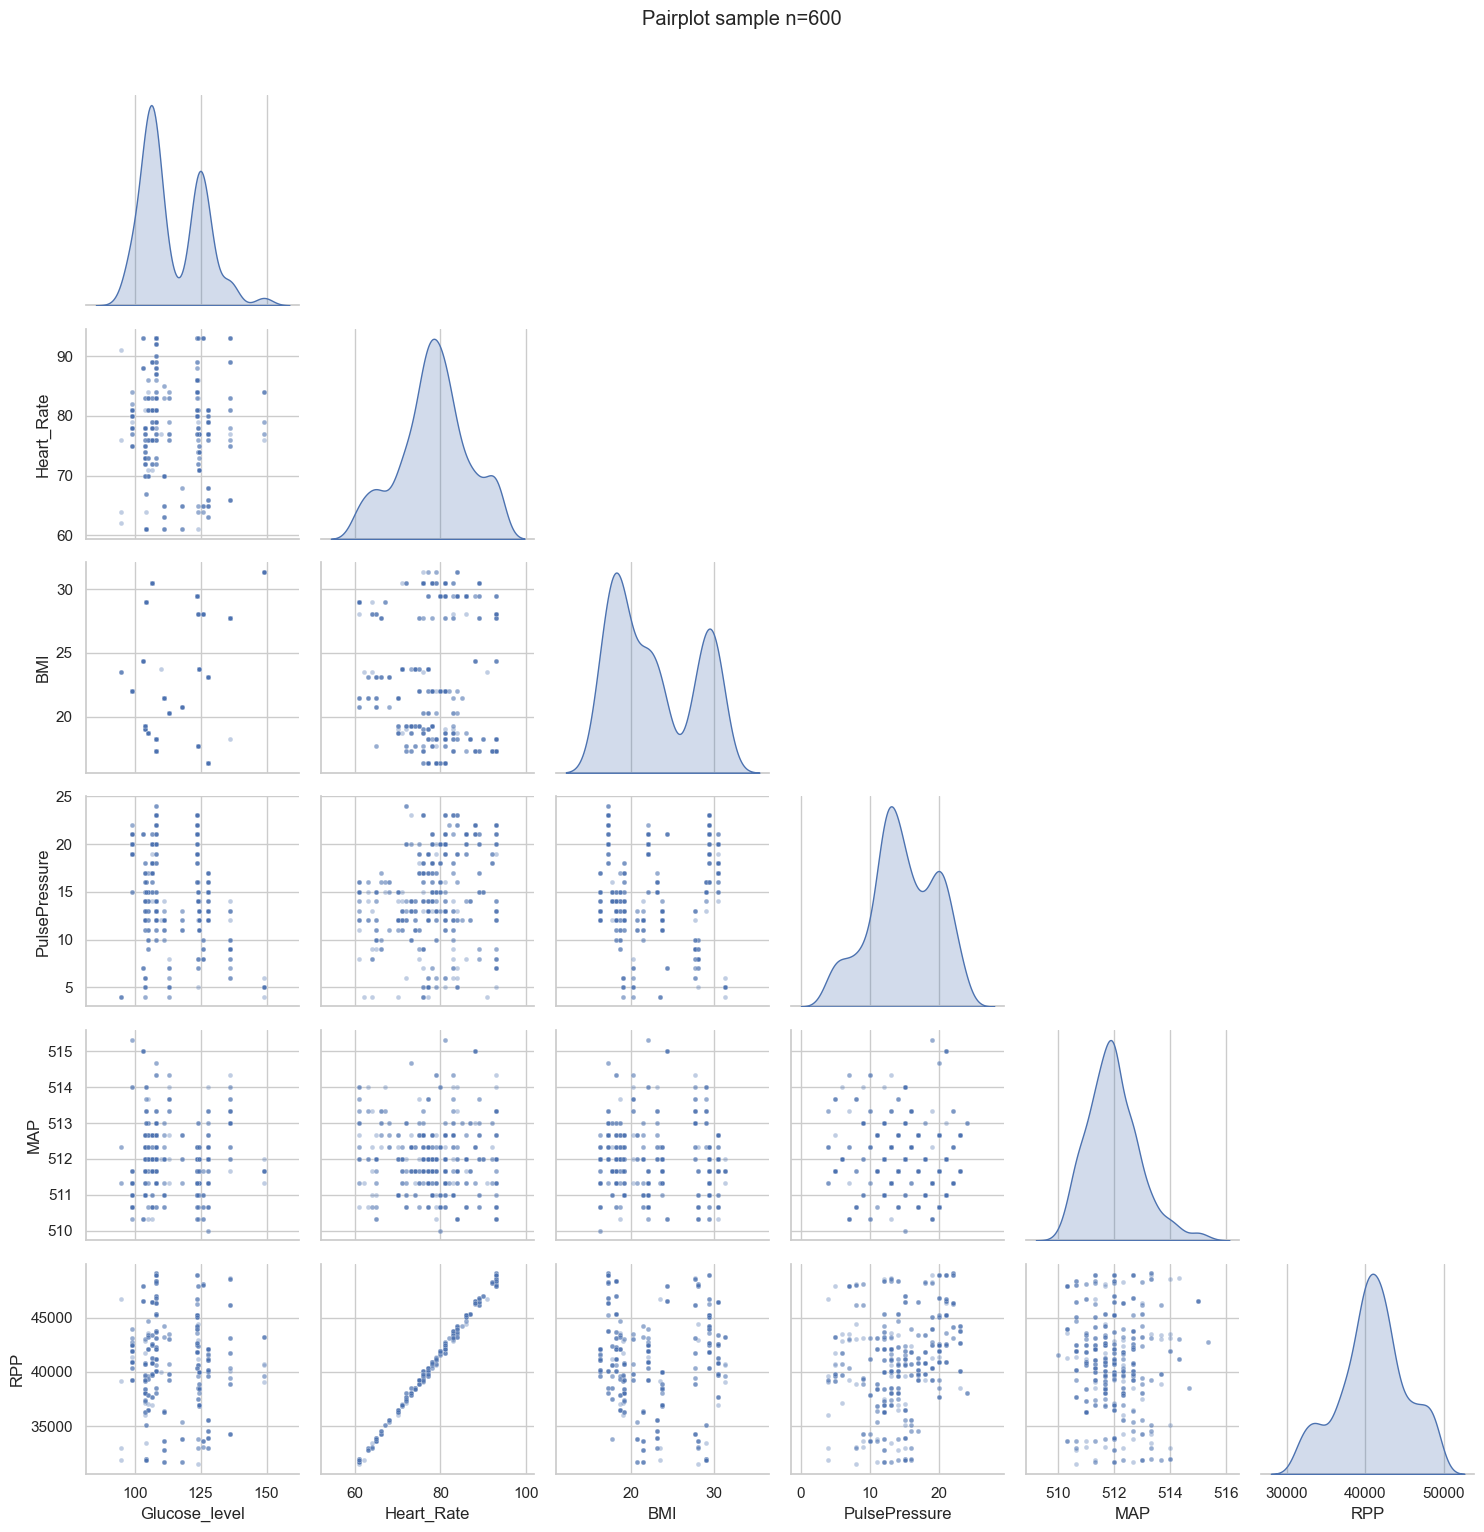

In [73]:
# Pairplot on a small random sample (numeric subset only)
sample_cols = ["Glucose_level", "Heart_Rate", "BMI", "PulsePressure", "MAP", "RPP"]
sample_cols = [c for c in sample_cols if c in df_final.columns]
g = min(600, len(df_final))
rs = df_final.sample(g, random_state=7)
sns.pairplot(rs[sample_cols], corner=True, diag_kind="kde", plot_kws={"alpha": 0.35, "s": 12})
plt.suptitle(f"Pairplot sample n={g}", y=1.02)
plt.tight_layout()
plt.show()


## 8. Data-driven decisions — summary

| Finding | Decision |
|--------|----------|
| `index`, `pl` correlate with structure / order | **Drop** from features |
| Random split looks unrealistically strong | Use **GroupSplit by `Patient_Id`** |
| Same physiology → multiple glucose labels | **Aggregate** to median per state |
| Massive duplicate rows | **Deduplicate** |
| Waveform peaks are sensor-scale | Do not apply **mmHg BP** hard limits; use **IQR** on signals |
| Few patients | Report as **prototype**; plan richer data / hardware |

**Output artifact:** `clean-dataset-relevant.csv` + `build_relevant_dataset.py` + report JSON.
